# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Xin Qi Huang| 6345735 |
| Meijne Bolger| 6213898|
| Hendrik De Mulder| 6350143 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Xin', 'Meijne','Hendrik']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Kalibreren | 11.45 |
| Mijlpaal 2: Meetopstelling testen | 12.00 |
| Mijlpaal 3: Iteratie poging| 14.30 |
| Mijlpaal 4: Iteratie poging 2| 16.00 |
| Mijlpaal 5: Iteratie | 16.30 |
| Pauze 1| 12.30 - 13.30 |
| Pauze 2| 15.00 - 15.15 |


## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit 

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [27]
<img src="Meetopstelling.jpeg" width="400">

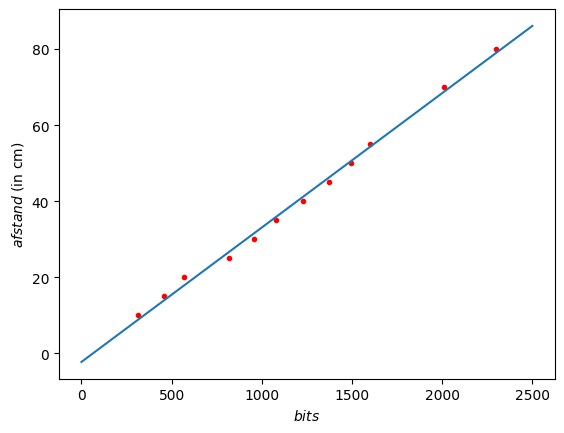

[ 0.03531933 -2.22004156]


In [3]:
# verwerk hier jullie kalibratiemetingen

afstand = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 70, 80])
bits = np.array([315, 460, 570, 816, 955, 1077, 1230, 1375, 1495, 1600, 2010, 2300])

def functionfit(x, a, b):
    return a*x + b
val, cov = curve_fit(functionfit, bits, afstand)


x_fit = np.linspace(0,2500,1000)

plt.figure()
plt.plot(bits, afstand, 'r.')
plt.plot(x_fit, functionfit(x_fit, *val))
plt.xlabel('$bits$')
plt.ylabel('$afstand$ (in cm)')
plt.show()

print(val)

## Opdracht 4: Test meting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  42.26
1   0  30   0  20  41.30
2  40   0  30   0  42.93
3  30   0  20   0  42.26


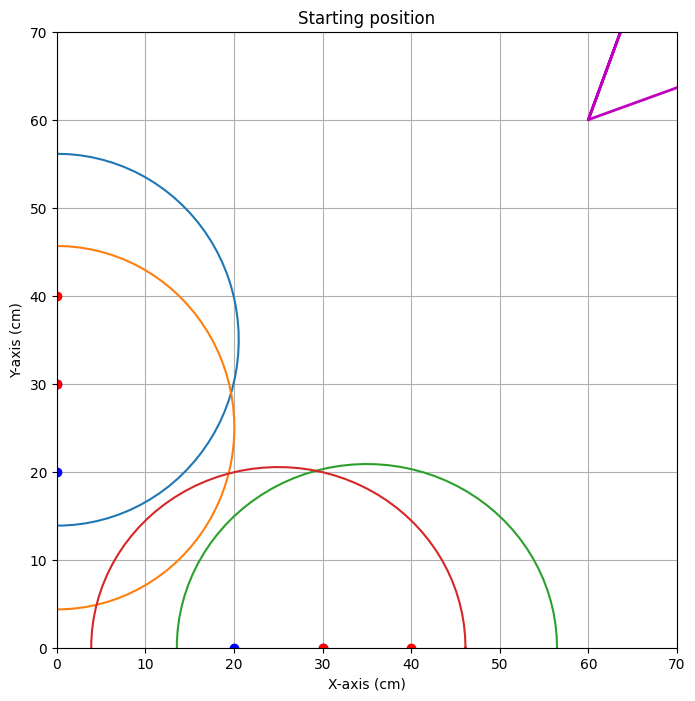


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.767


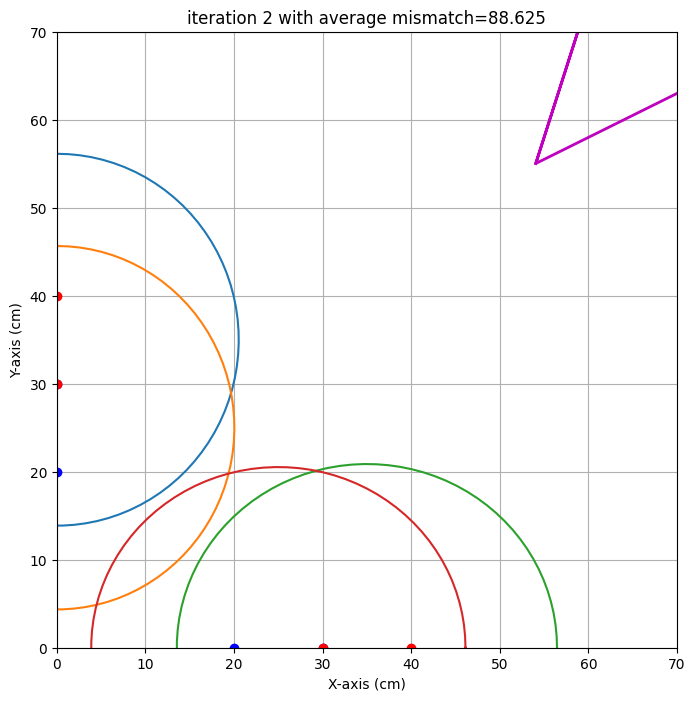

end iteration 2 with average mismatch=88.625


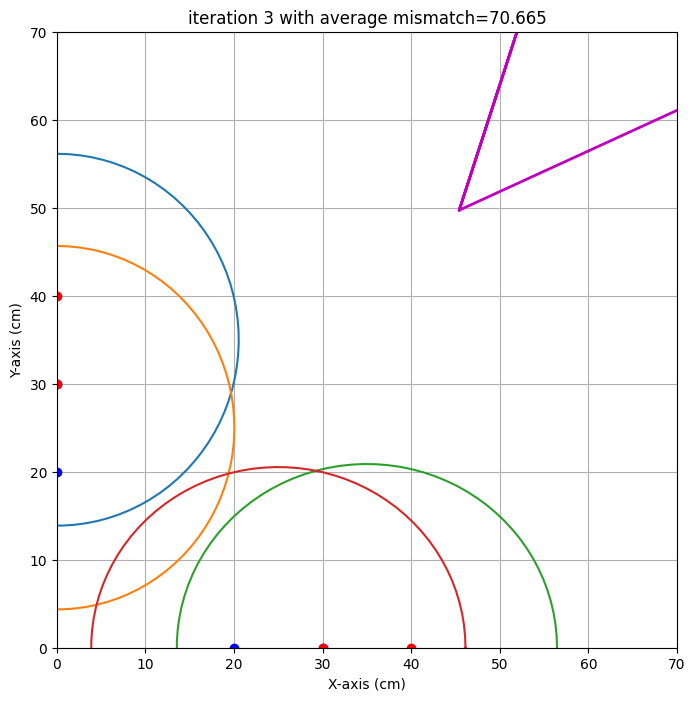

end iteration 3 with average mismatch=70.665


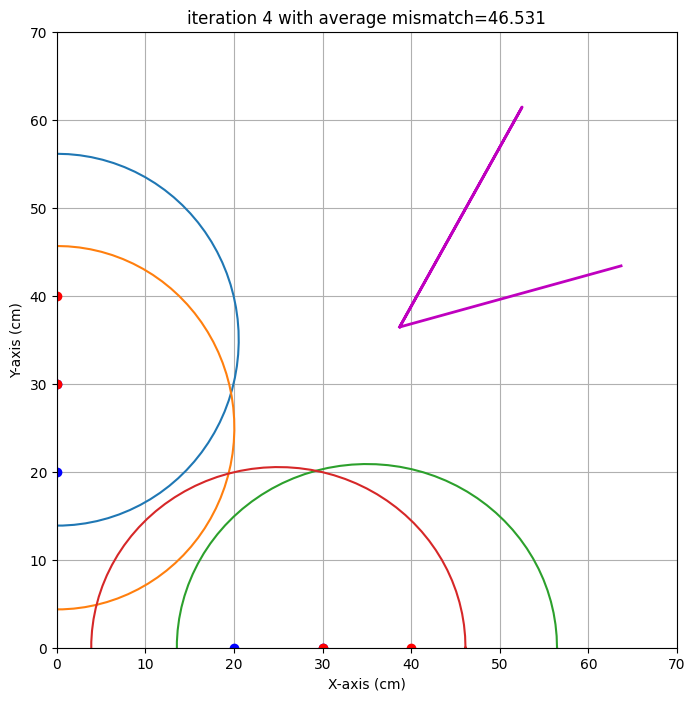

end iteration 4 with average mismatch=46.531


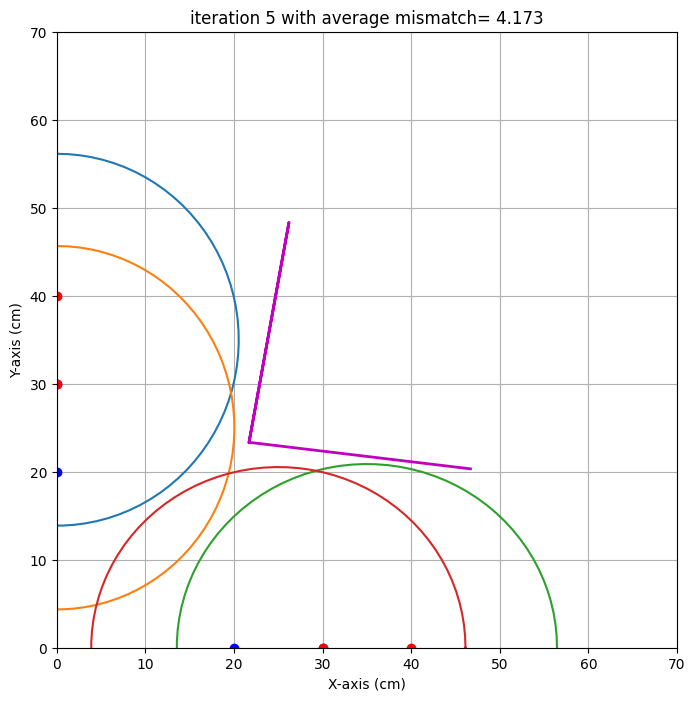

end iteration 5 with average mismatch= 4.173


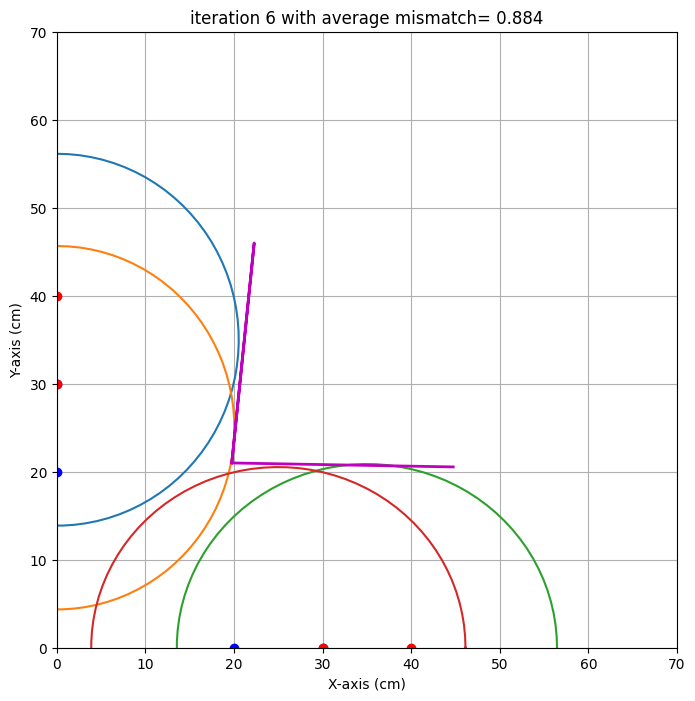

end iteration 6 with average mismatch= 0.884


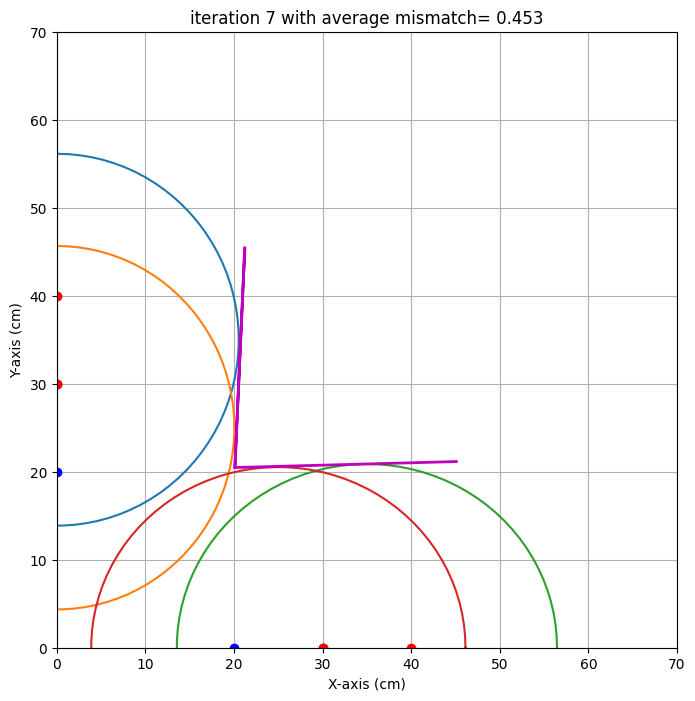

end iteration 7 with average mismatch= 0.453


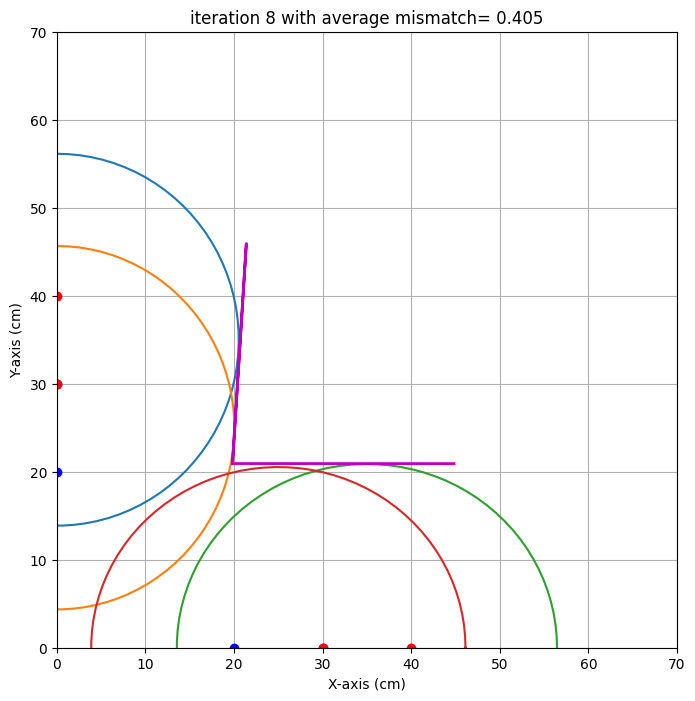

end iteration 8 with average mismatch= 0.405
end iteration 9 with average mismatch= 0.389


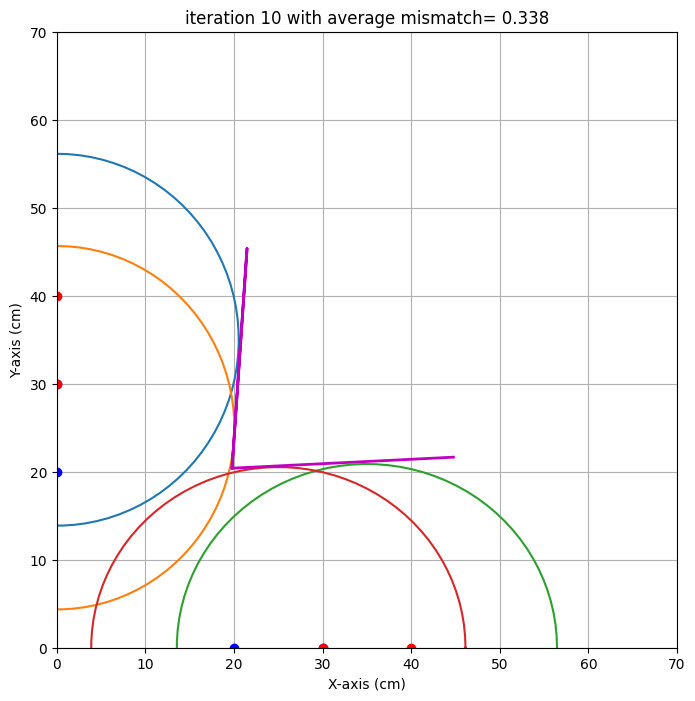

end iteration 10 with average mismatch= 0.338
end iteration 11 with average mismatch= 0.334
end iteration 12 with average mismatch= 0.331
end iteration 13 with average mismatch= 0.331
end iteration 14 with average mismatch= 0.330
end iteration 15 with average mismatch= 0.330


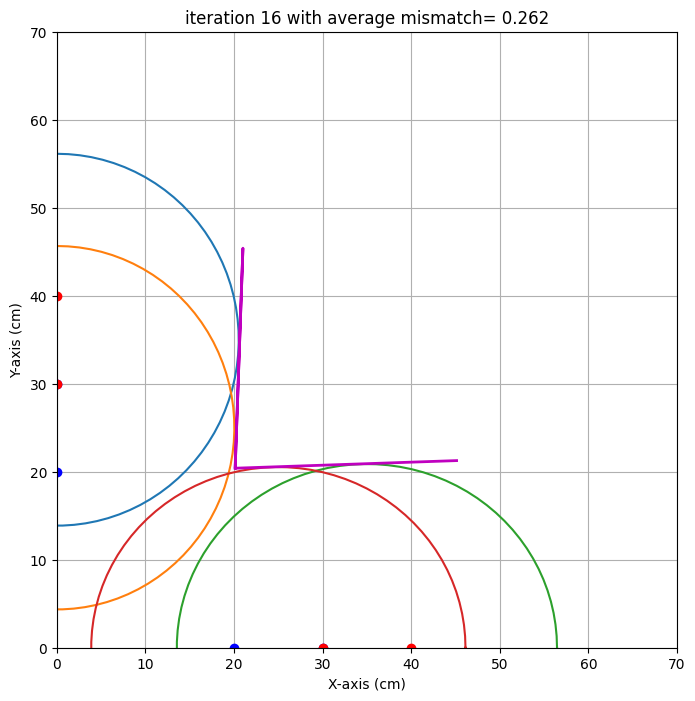

end iteration 16 with average mismatch= 0.262


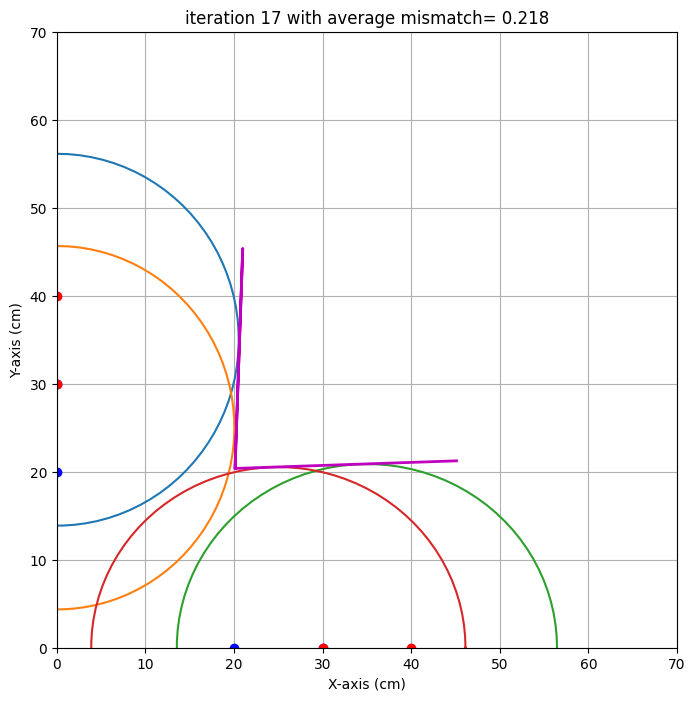

end iteration 17 with average mismatch= 0.218
end iteration 18 with average mismatch= 0.217
end iteration 19 with average mismatch= 0.217


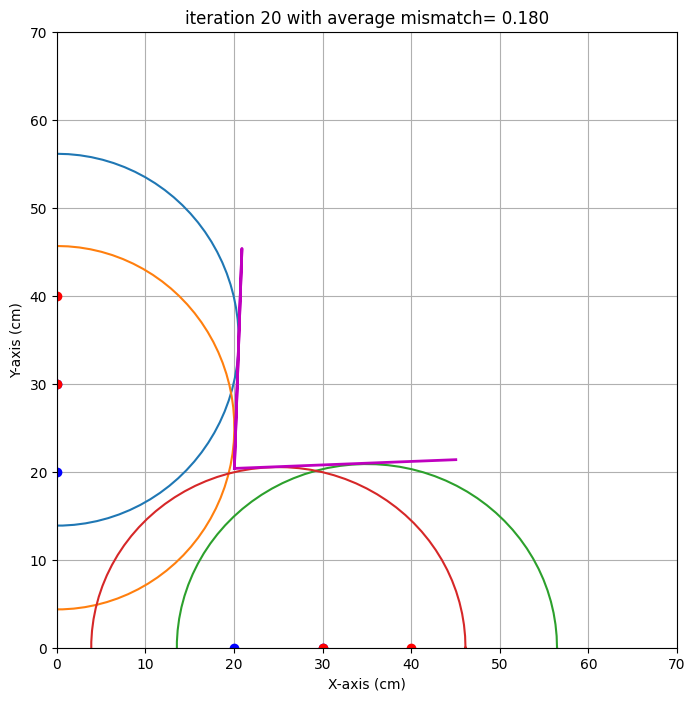

end iteration 20 with average mismatch= 0.180
end iteration 21 with average mismatch= 0.174
end iteration 22 with average mismatch= 0.174
end iteration 23 with average mismatch= 0.174
end iteration 24 with average mismatch= 0.174
end iteration 25 with average mismatch= 0.174
end iteration 26 with average mismatch= 0.174
end iteration 27 with average mismatch= 0.174
end iteration 28 with average mismatch= 0.174
end iteration 29 with average mismatch= 0.174
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.174
###############################################################################
end of iteration  30
Best alpha=   2.27 with uncertainty=   0.00
Best beta =   1.96 with uncertainty=   0.00
Best x0   =  20.03 with uncertainty=   0.00
Best y0   =  20.37 with uncertainty=   0.00
##########################################################

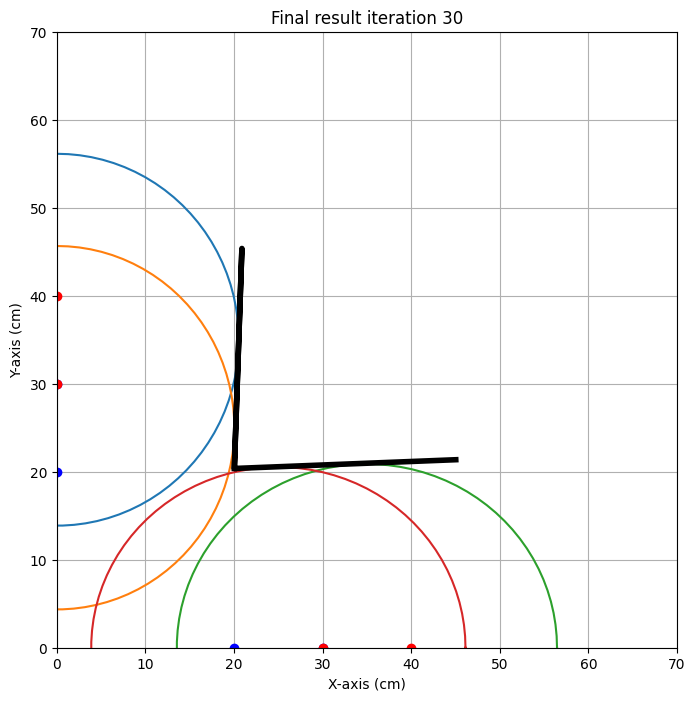

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,42.26],
    [0,30,0,20,41.30],
    # [0,10,0,20,99.97],
    [40,0,30,0,42.93],
    [30,0,20,0,42.26],
    # [10,0,20,0,103.75],
    # [10,0,0,10,104.53]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 20.0 cm met een standaardafwijking van 0.0 cm 
y0: 20.4 cm met een standaardafwijking van 0.0 cm 
alpha: 2.3 graden met een standaardafwijking van 0.0 graad 
beta: 2.0 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Hendrik]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="iteratie_1.jpeg" width="400">

#### algoritme [Meijne]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="iteratie_2.jpeg" width="400">

#### algoritme [Xin Qi]
Voeg een foto in van het algoritme van het derde groepslid
<img src="iteratie_3.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!
# We hebben perongeluk de plannen al samengevoegd voor opdracht 6, oops. 
# Besproken met TA asper en Sjoerd.

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':42,  #zelf aanvullen,
           'y0':27.5, #zelf aanvullen,
           'alpha' :0, #zelf aanvullen,
           'beta' :24,
          }     

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'naam1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   [0, 25.0, 0, 35.0, 87.13],
   [0, 35.0, 0, 45.0, 90.0],
   [45.0, 0, 55.0 ,0, 56.0],
   [55.0, 0 , 65.0 ,0, 55.0],
   # [1.0, 0 , 1.0 ,0, 1.0],
    ]),
       'naam2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ]),
       'naam3' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

## Opdracht 7: Evaluatie.

Running the imaging algorithm with the following data:
     xs    ys    xr    yr      R
0   0.0  25.0   0.0  35.0  87.13
1   0.0  35.0   0.0  45.0  90.00
2  45.0   0.0  55.0   0.0  56.00
3  55.0   0.0  65.0   0.0  55.00


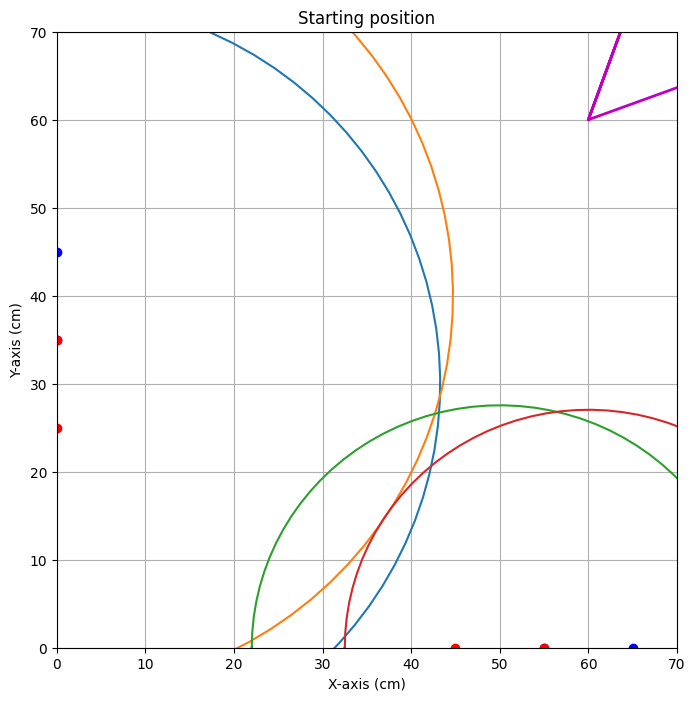


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.918


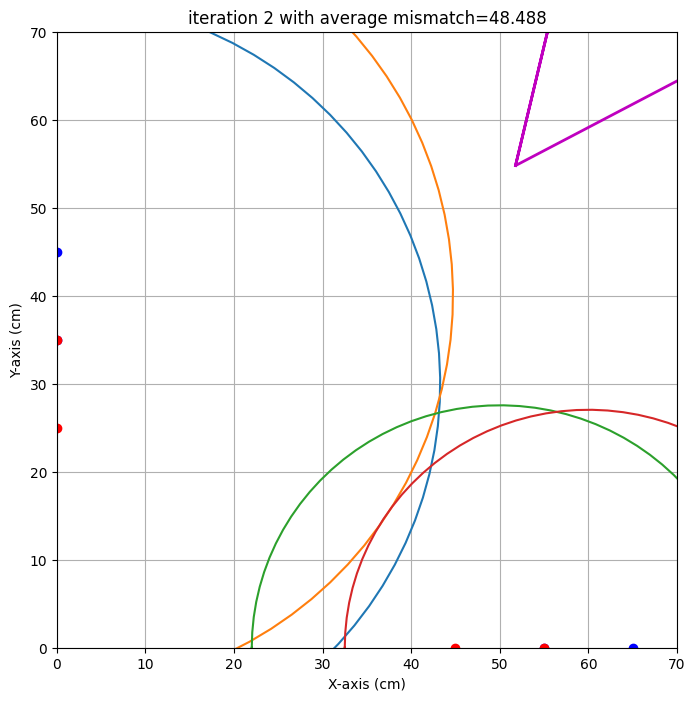

end iteration 2 with average mismatch=48.488


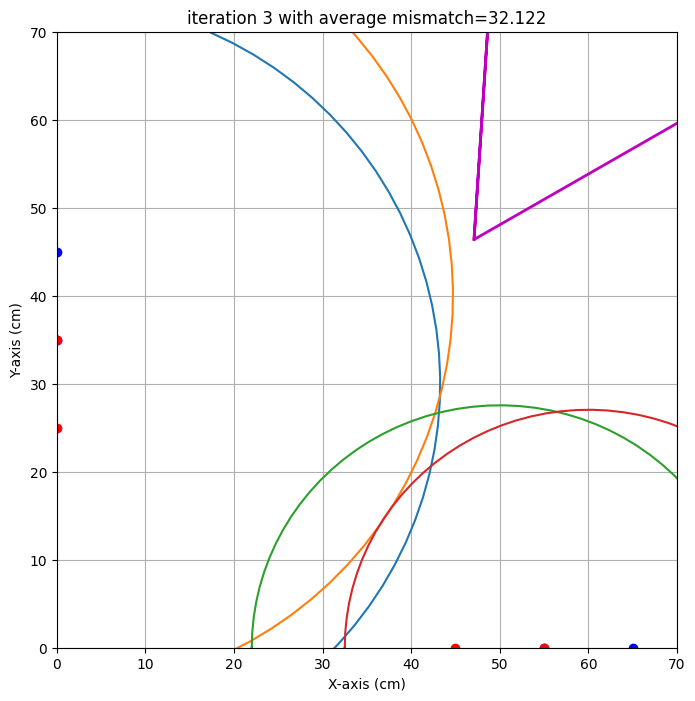

end iteration 3 with average mismatch=32.122


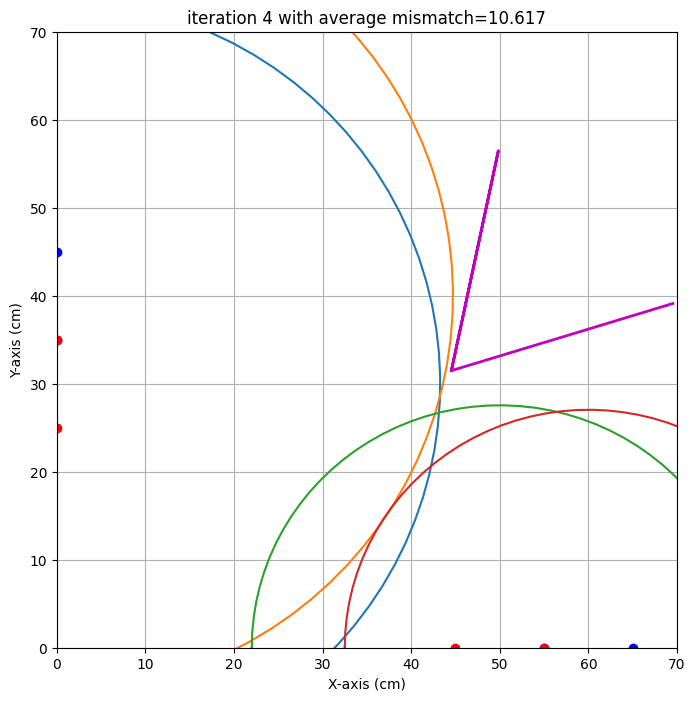

end iteration 4 with average mismatch=10.617


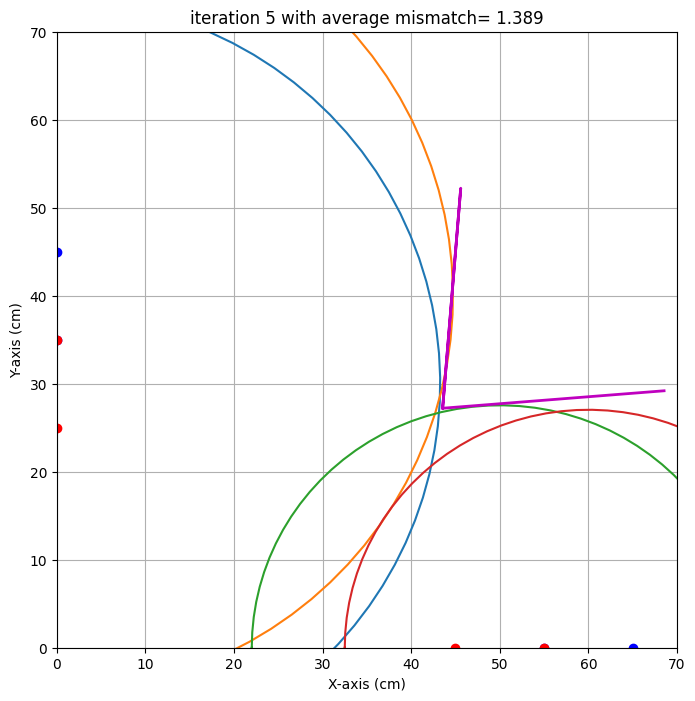

end iteration 5 with average mismatch= 1.389


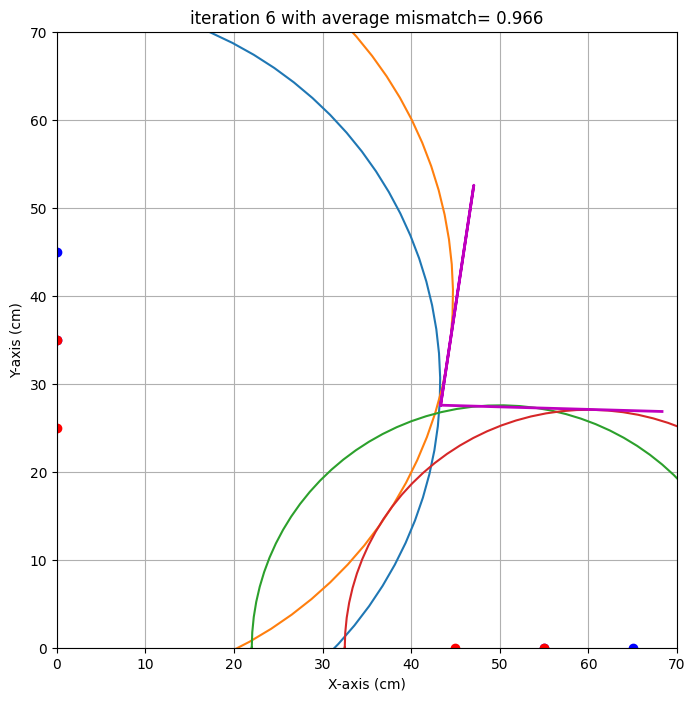

end iteration 6 with average mismatch= 0.966


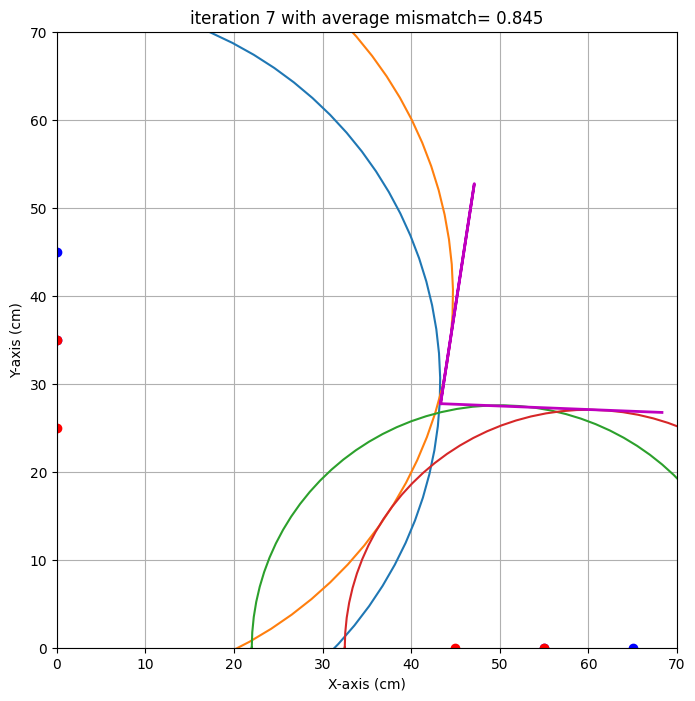

end iteration 7 with average mismatch= 0.845


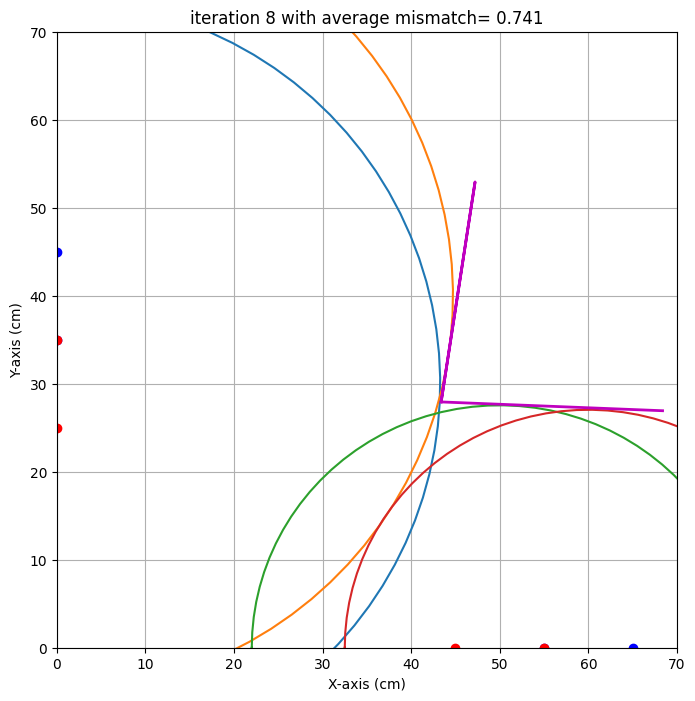

end iteration 8 with average mismatch= 0.741
end iteration 9 with average mismatch= 0.676
end iteration 10 with average mismatch= 0.626
end iteration 11 with average mismatch= 0.625
end iteration 12 with average mismatch= 0.625
end iteration 13 with average mismatch= 0.625
end iteration 14 with average mismatch= 0.625
end iteration 15 with average mismatch= 0.625
end iteration 16 with average mismatch= 0.625
end iteration 17 with average mismatch= 0.625
end iteration 18 with average mismatch= 0.625
end iteration 19 with average mismatch= 0.625
end iteration 20 with average mismatch= 0.625
end iteration 21 with average mismatch= 0.625
end iteration 22 with average mismatch= 0.625
end iteration 23 with average mismatch= 0.625
end iteration 24 with average mismatch= 0.625
end iteration 25 with average mismatch= 0.625
end iteration 26 with average mismatch= 0.625
end iteration 27 with average mismatch= 0.625
end iteration 28 with average mismatch= 0.574
end iteration 29 with average mismat

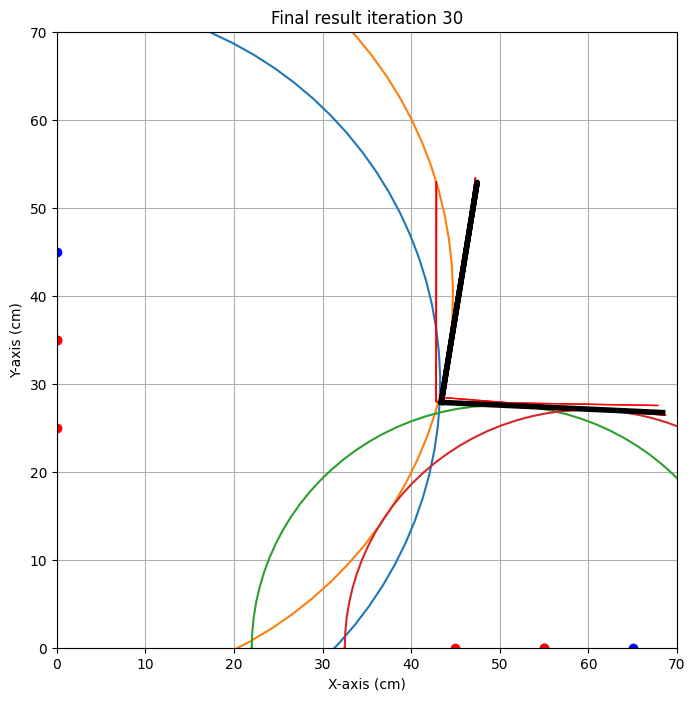

{'alpha': np.float64(-2.654752395673705), 'alpha_eps': np.float64(1.9223267409287286), 'beta': np.float64(9.233603337793879), 'beta_eps': np.float64(9.20730326900056), 'x0': np.float64(43.389158525131755), 'x0_eps': np.float64(0.5529301317433166), 'y0': np.float64(27.879490883275004), 'y0_eps': np.float64(0.5394948608397563)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
data = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   [0, 25.0, 0, 35.0, 87.13],
   [0, 35.0, 0, 45.0, 90.0],
   [45.0, 0, 55.0 ,0, 56.0],
   [55.0, 0 , 65.0 ,0, 55.0],
   # [1.0, 0 , 1.0 ,0, 1.0],
    ])
resultaat = imagingDEF.imagingDEF(data)
print(resultaat)
# for studentName in studentNames:
#     print(studentName)
#     resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
#     print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.

txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaat['x0'],
                 x0_eps=resultaat['x0_eps'],
                 y0=resultaat['y0'],
                 y0_eps=resultaat['y0_eps'],
                 alpha=resultaat['alpha'],
                 alpha_eps=resultaat['alpha_eps'],
                 beta=resultaat['beta'],
                 beta_eps=resultaat['beta_eps']))

# for studentName in studentNames:
#     txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
#     txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
#     txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
#     txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
#     print(txt.format(naam = studentName,
#                      x0Target=targets['x0'],
#                      x0=resultaat[studentName]['x0'],
#                      x0_eps=resultaat[studentName]['x0_eps'],
#                      y0Target=targets['y0'],
#                      y0=resultaat[studentName]['y0'],
#                      y0_eps=resultaat[studentName]['y0_eps'],
#                      alphaTarget=targets['alpha'],
#                      alpha=resultaat[studentName]['alpha'],
#                      alpha_eps=resultaat[studentName]['alpha_eps'],
#                      betaTarget=targets['beta'],
#                      beta=resultaat[studentName]['beta'],
#                      beta_eps=resultaat[studentName]['beta_eps']))

x0: 43.4 cm met een standaardafwijking van 0.6 cm 
y0: 27.9 cm met een standaardafwijking van 0.5 cm 
alpha: -2.7 graden met een standaardafwijking van 1.9 graad 
beta: 9.2 graden met een standaardafwijking van 9.2 graad 



## Opdracht 8: Iteratie1+. 16.00 begonnen met iteratie.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Einditeratie: ![Alt](Eind_iteratie.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs    ys  xr    yr      R
0   0  42.5   0  52.5  82.73
1   0  47.5   0  57.5  81.94
2  44   0.0  54   0.0  85.00
3  54   0.0  64   0.0  88.00


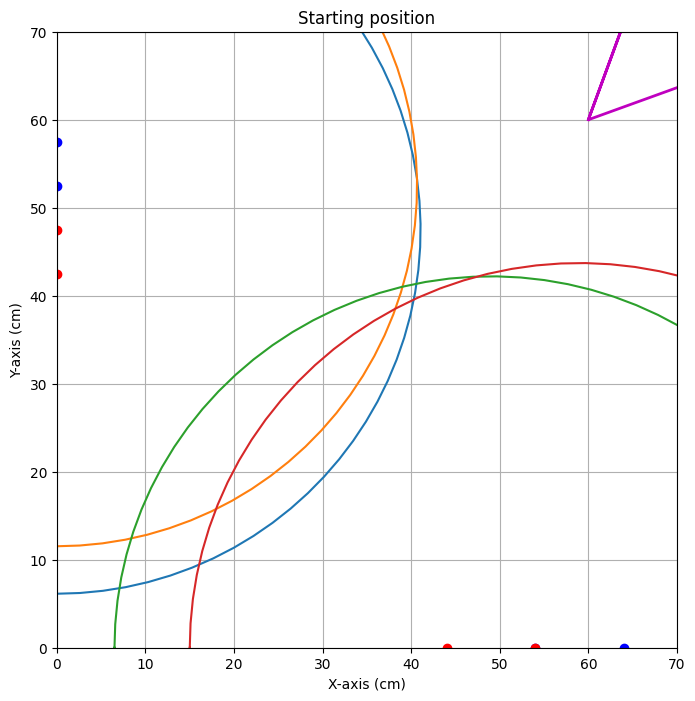


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.472


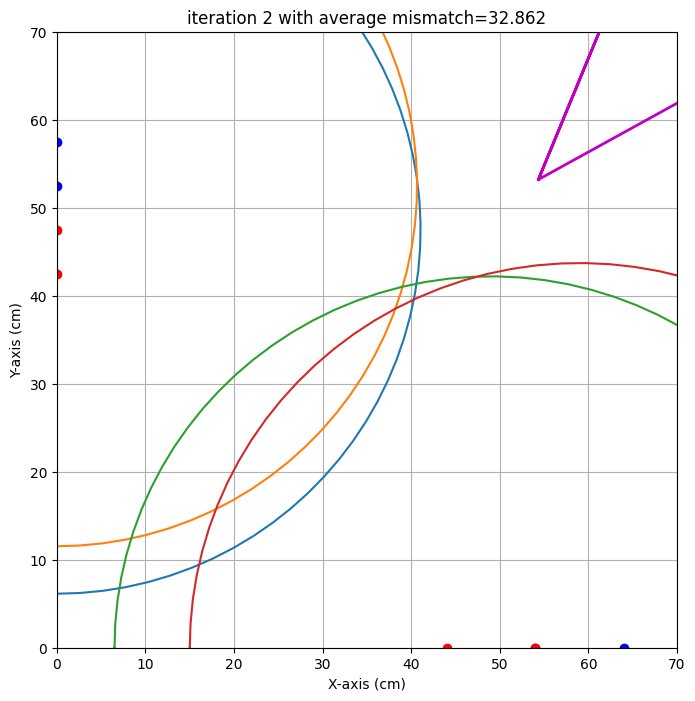

end iteration 2 with average mismatch=32.862


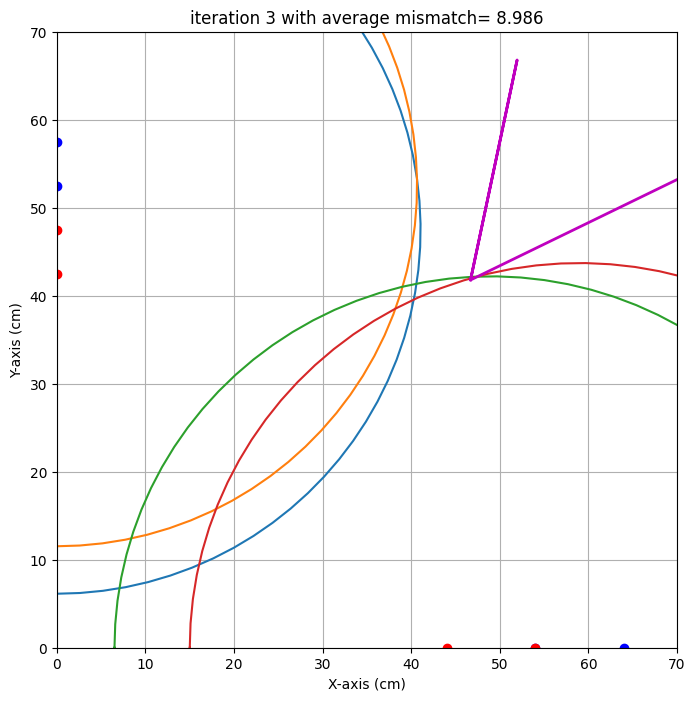

end iteration 3 with average mismatch= 8.986


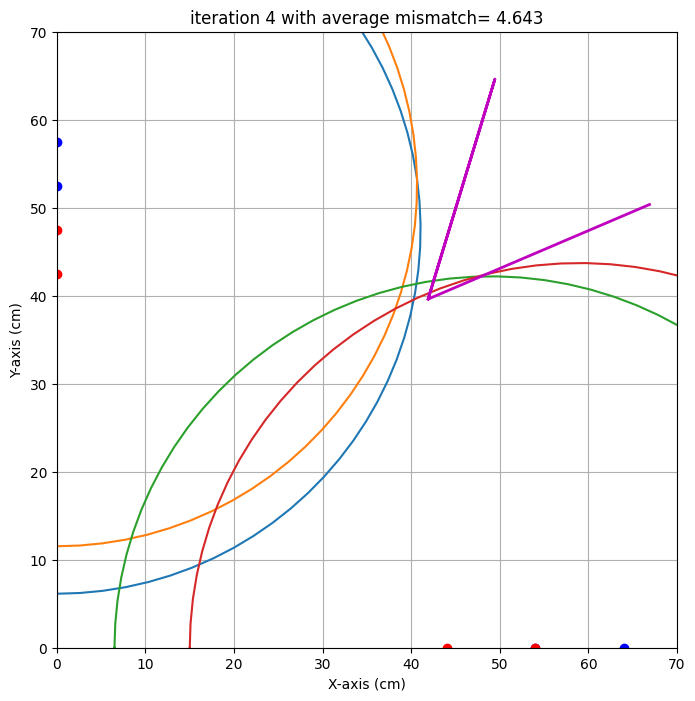

end iteration 4 with average mismatch= 4.643


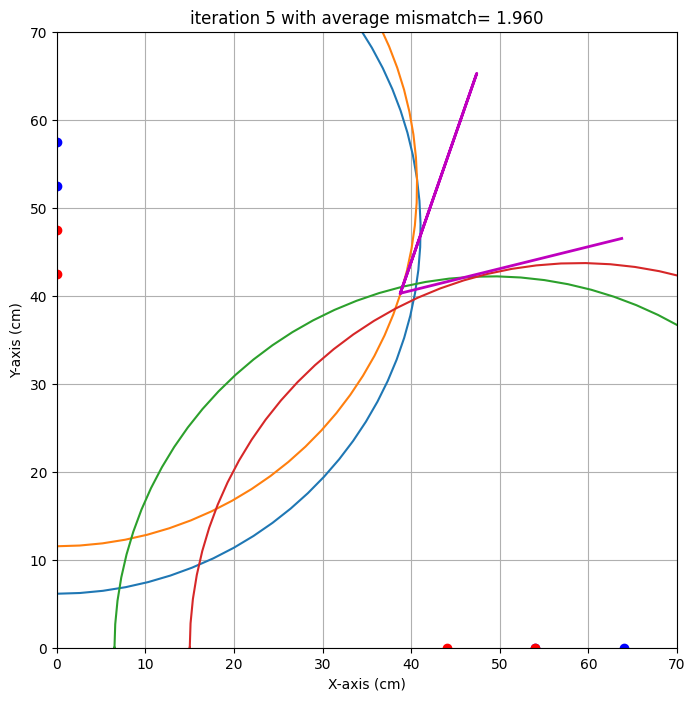

end iteration 5 with average mismatch= 1.960


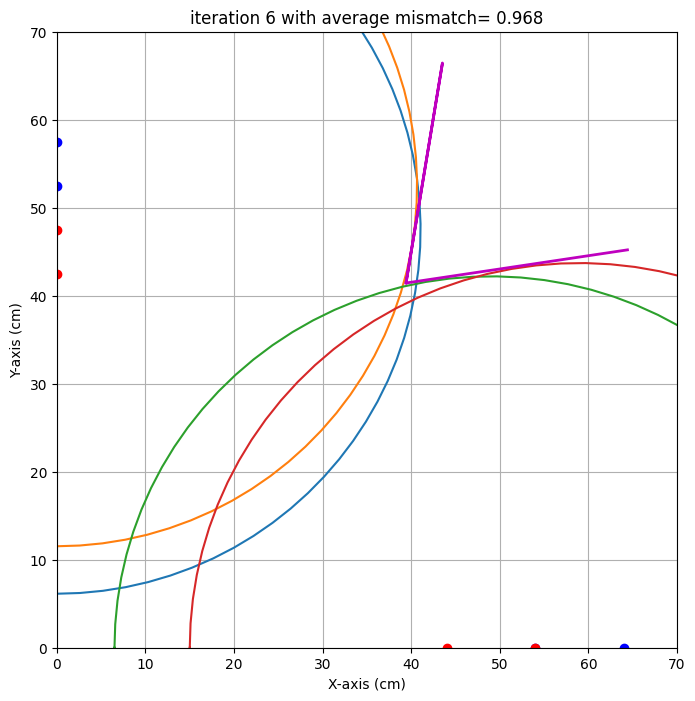

end iteration 6 with average mismatch= 0.968
end iteration 7 with average mismatch= 0.937
end iteration 8 with average mismatch= 0.929


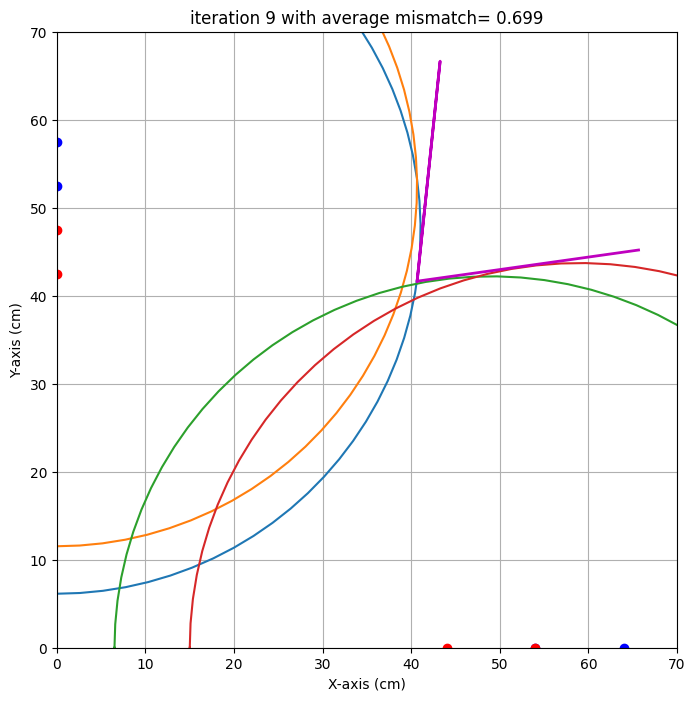

end iteration 9 with average mismatch= 0.699
end iteration 10 with average mismatch= 0.662
end iteration 11 with average mismatch= 0.624
end iteration 12 with average mismatch= 0.609
end iteration 13 with average mismatch= 0.607
end iteration 14 with average mismatch= 0.607
end iteration 15 with average mismatch= 0.607
end iteration 16 with average mismatch= 0.567


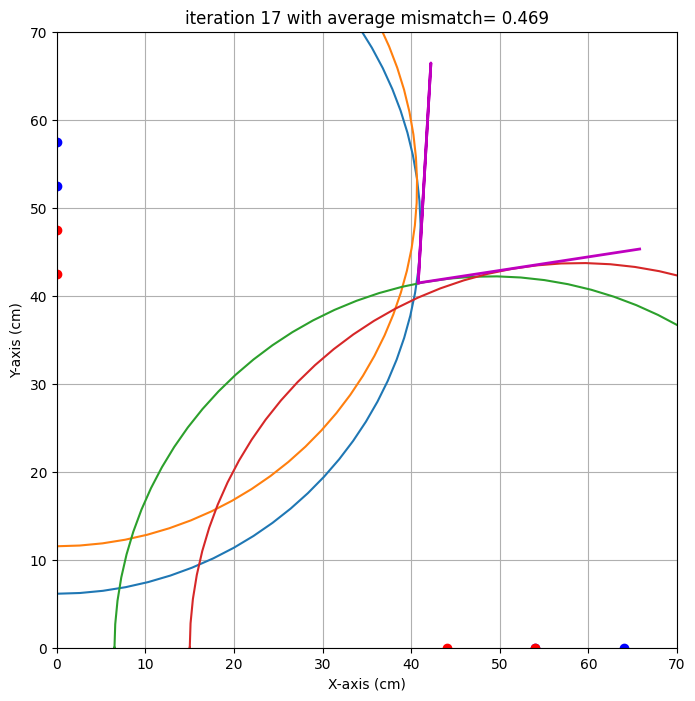

end iteration 17 with average mismatch= 0.469
end iteration 18 with average mismatch= 0.448
end iteration 19 with average mismatch= 0.448
end iteration 20 with average mismatch= 0.448
end iteration 21 with average mismatch= 0.448
end iteration 22 with average mismatch= 0.426


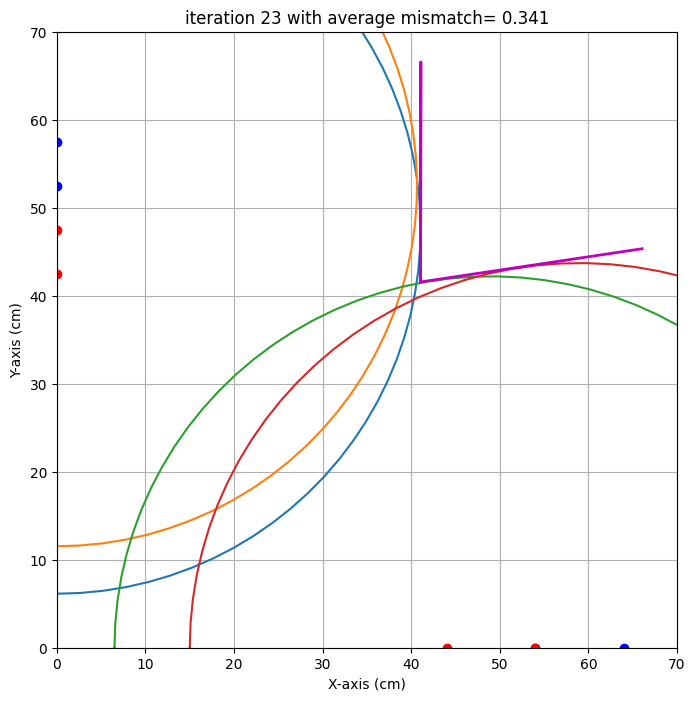

end iteration 23 with average mismatch= 0.341
end iteration 24 with average mismatch= 0.328
end iteration 25 with average mismatch= 0.324
end iteration 26 with average mismatch= 0.310
end iteration 27 with average mismatch= 0.289
end iteration 28 with average mismatch= 0.268


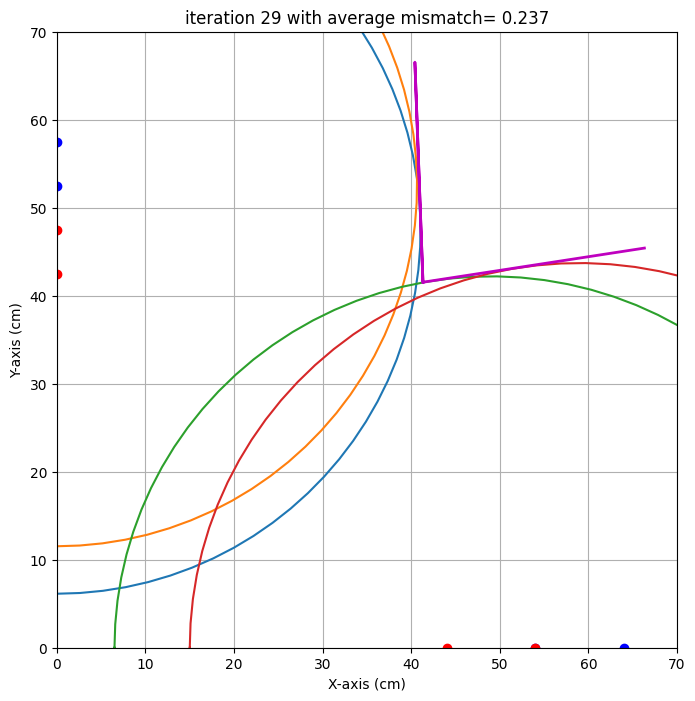

end iteration 29 with average mismatch= 0.237
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


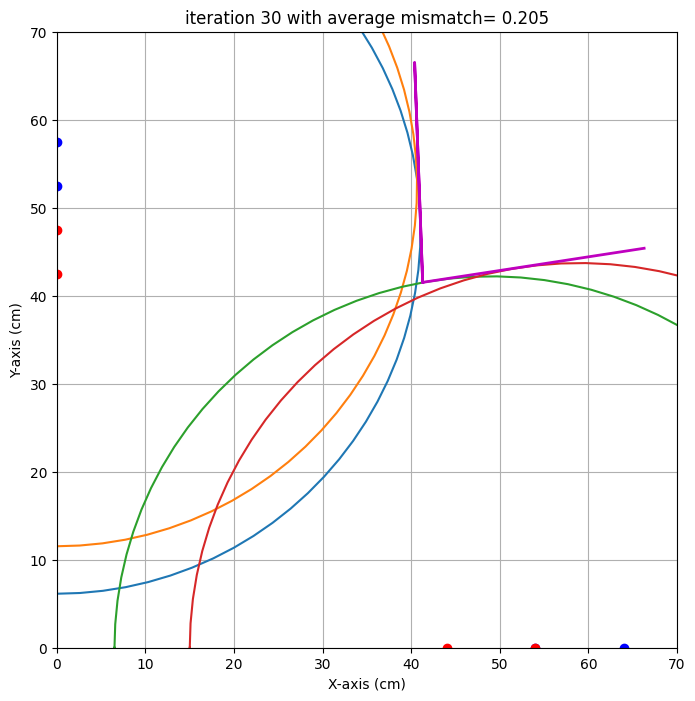

end iteration 30 with average mismatch= 0.205
###############################################################################
end of iteration  30
Best alpha=   8.81 with uncertainty=   0.85
Best beta =  -2.09 with uncertainty=   1.89
Best x0   =  41.30 with uncertainty=   0.27
Best y0   =  41.52 with uncertainty=   0.08
###############################################################################


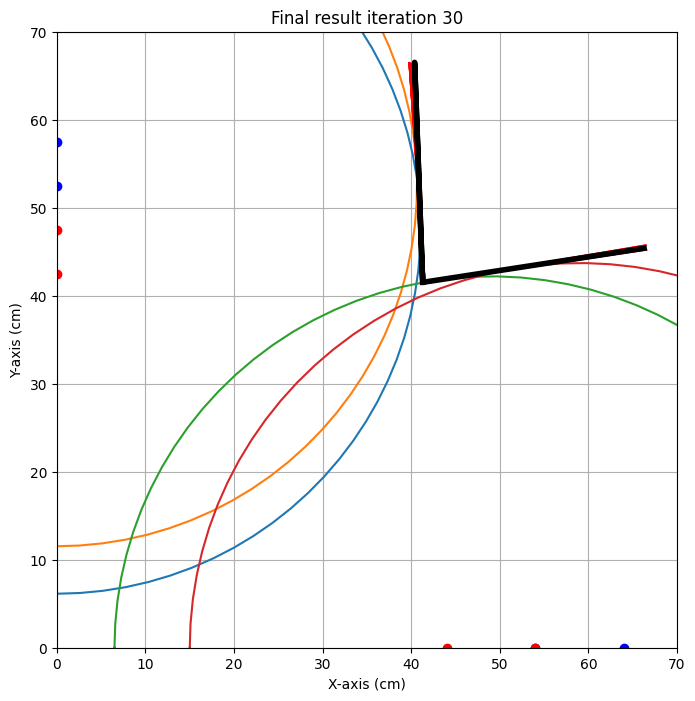

{'alpha': np.float64(8.80740806236456), 'alpha_eps': np.float64(0.8548590838428076), 'beta': np.float64(-2.090241293800705), 'beta_eps': np.float64(1.8894009500068747), 'x0': np.float64(41.29793356507854), 'x0_eps': np.float64(0.26566530697278523), 'y0': np.float64(41.519089880337106), 'y0_eps': np.float64(0.07738413360520013)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  31   0  41  56.5
1   0  41   0  51  60.5
2  30   0  40   0  54.2
3  40   0  50   0  59.6


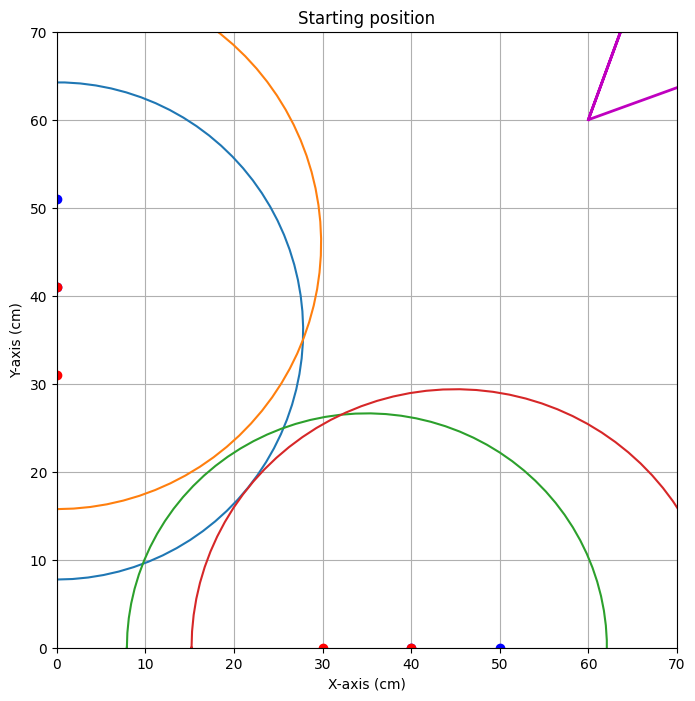


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=75.893


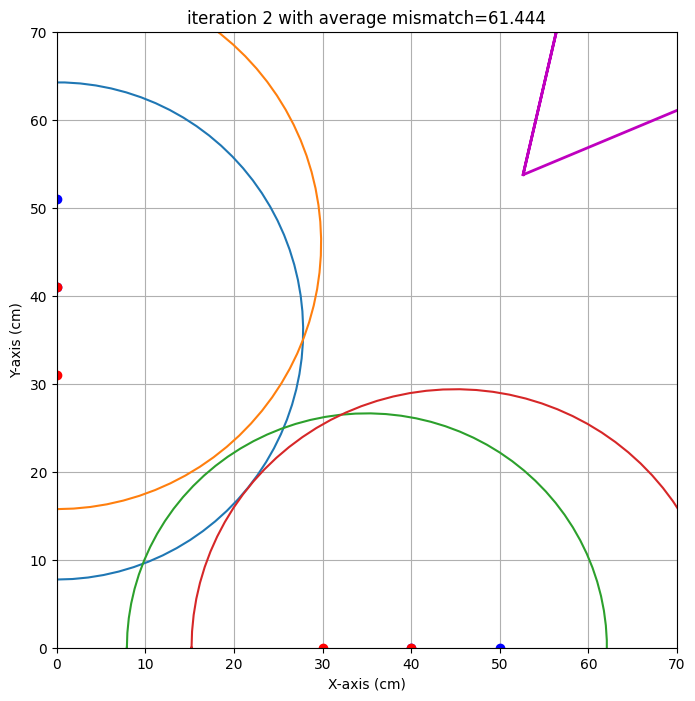

end iteration 2 with average mismatch=61.444


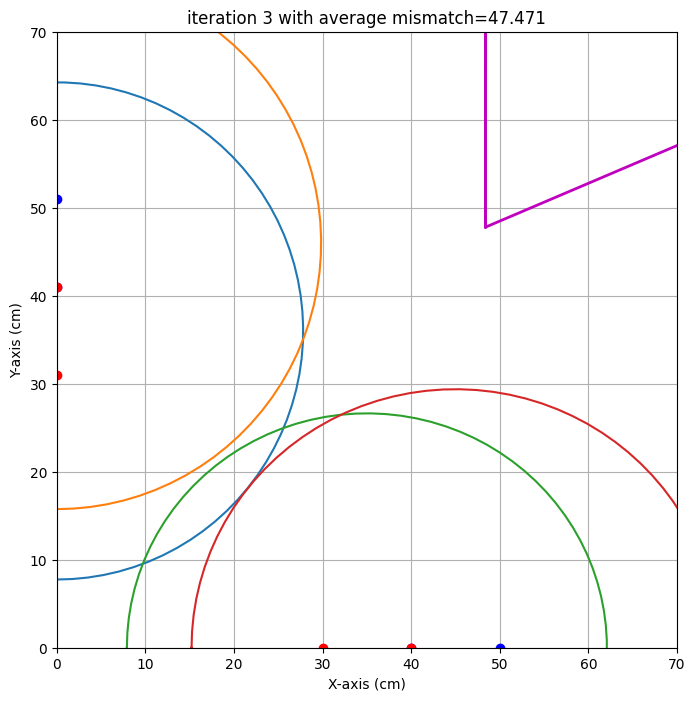

end iteration 3 with average mismatch=47.471


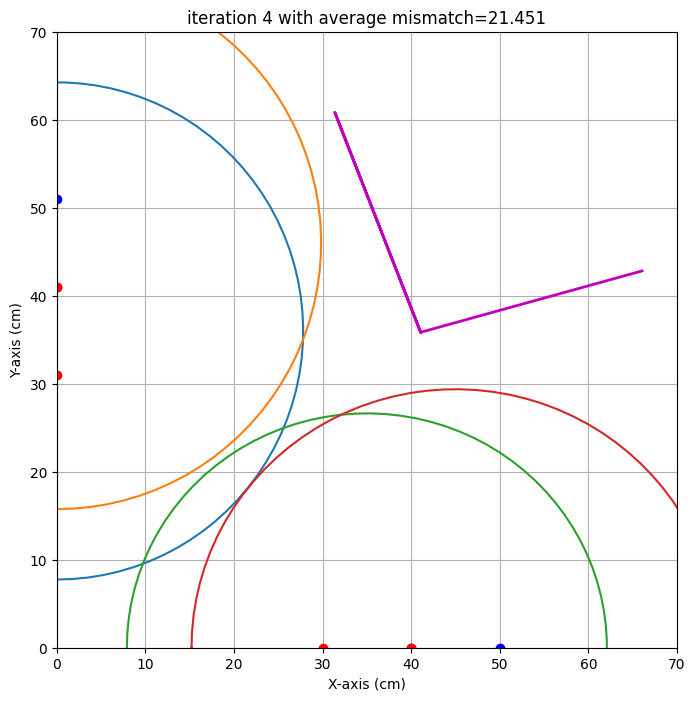

end iteration 4 with average mismatch=21.451


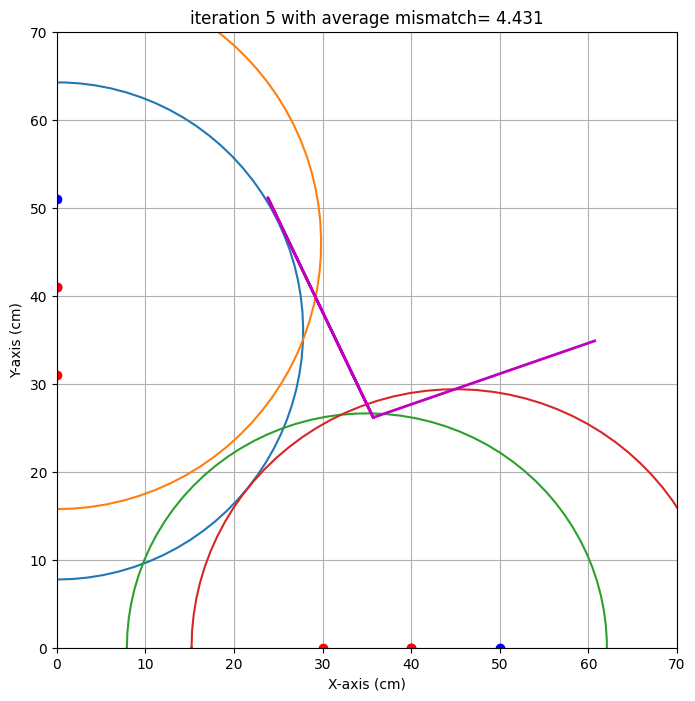

end iteration 5 with average mismatch= 4.431
end iteration 6 with average mismatch= 4.113


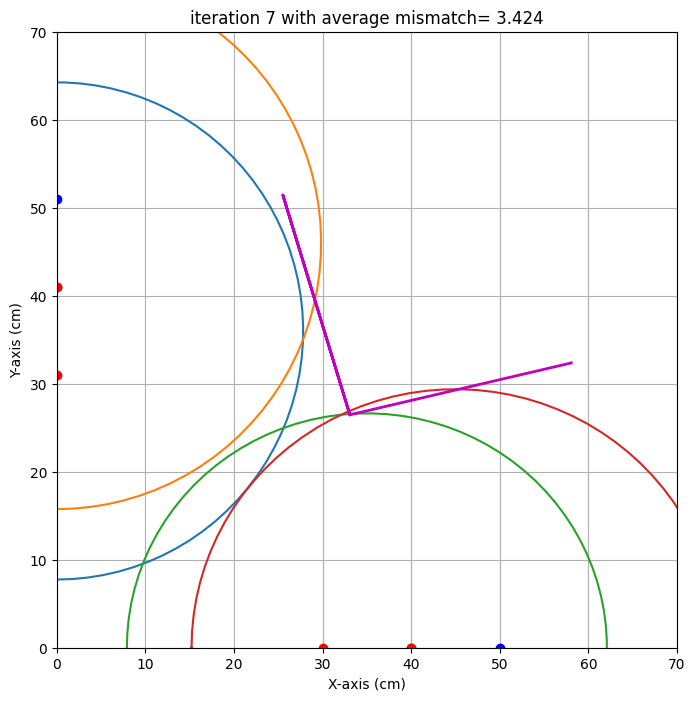

end iteration 7 with average mismatch= 3.424


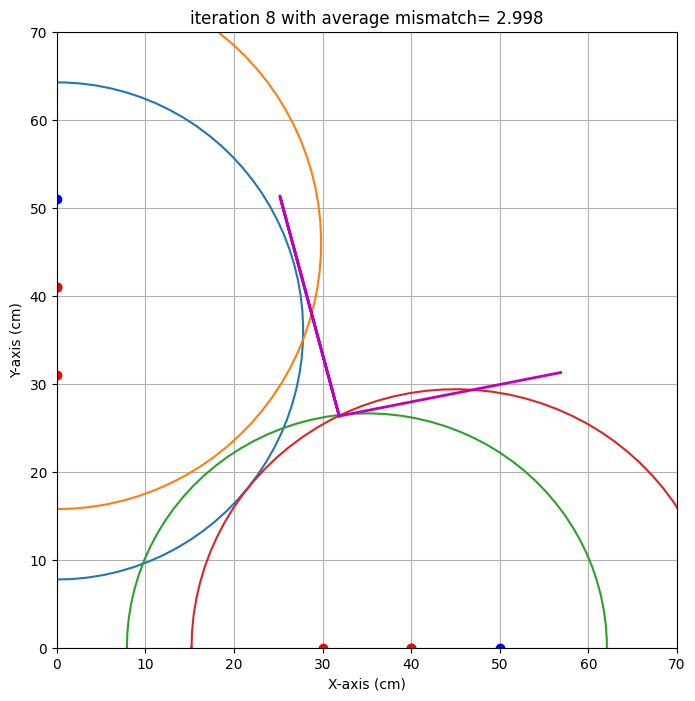

end iteration 8 with average mismatch= 2.998


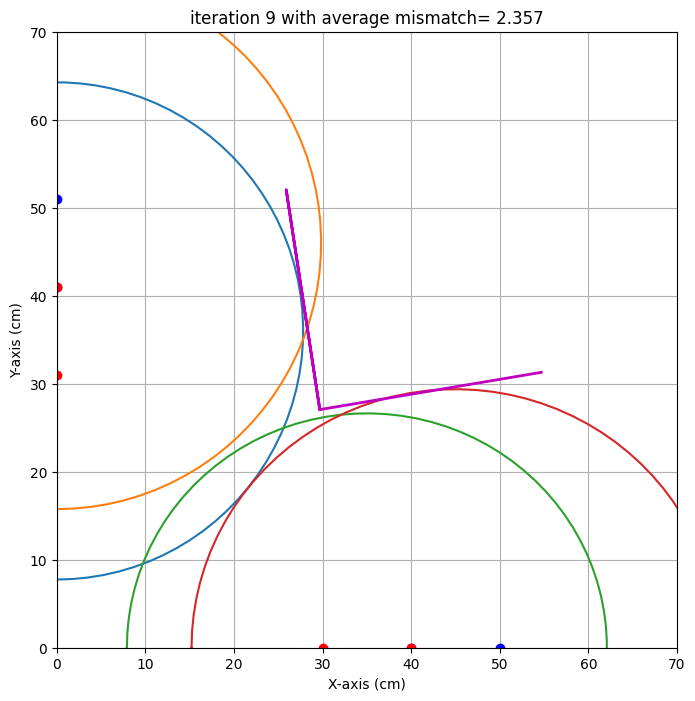

end iteration 9 with average mismatch= 2.357


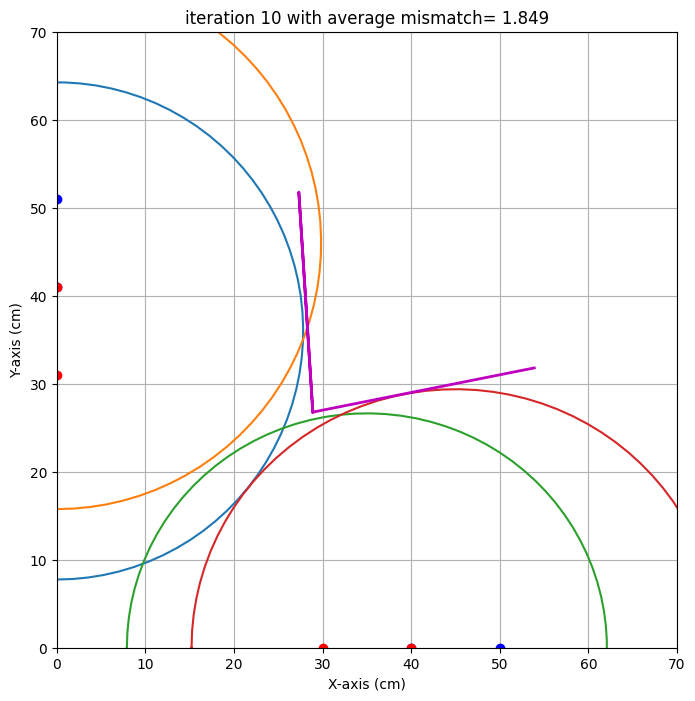

end iteration 10 with average mismatch= 1.849
end iteration 11 with average mismatch= 1.732


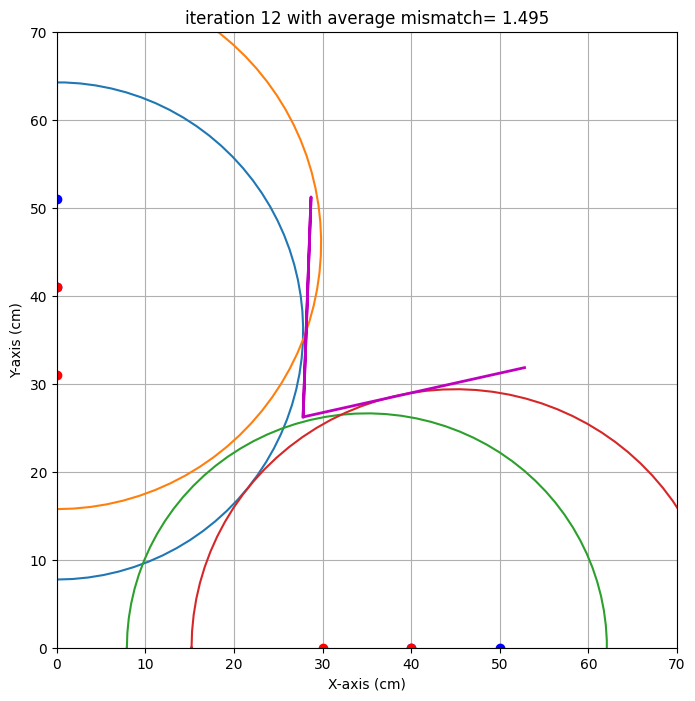

end iteration 12 with average mismatch= 1.495


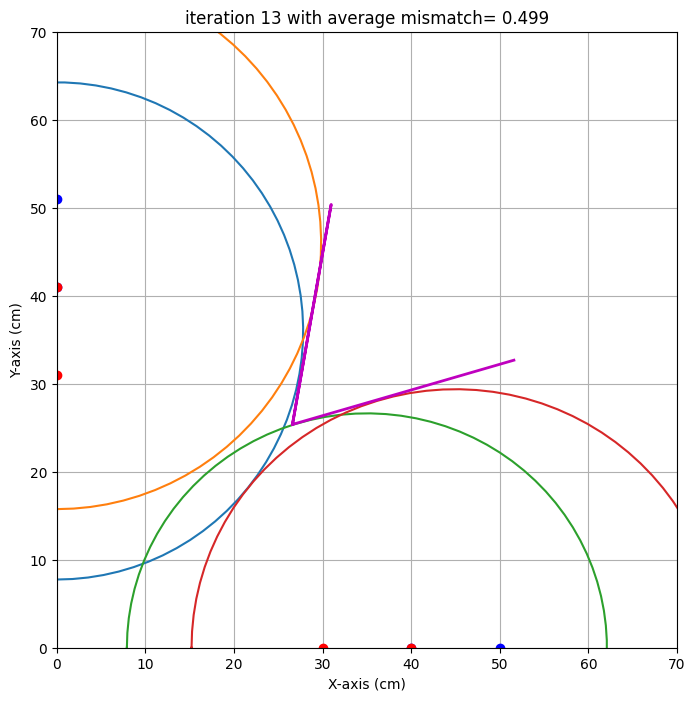

end iteration 13 with average mismatch= 0.499


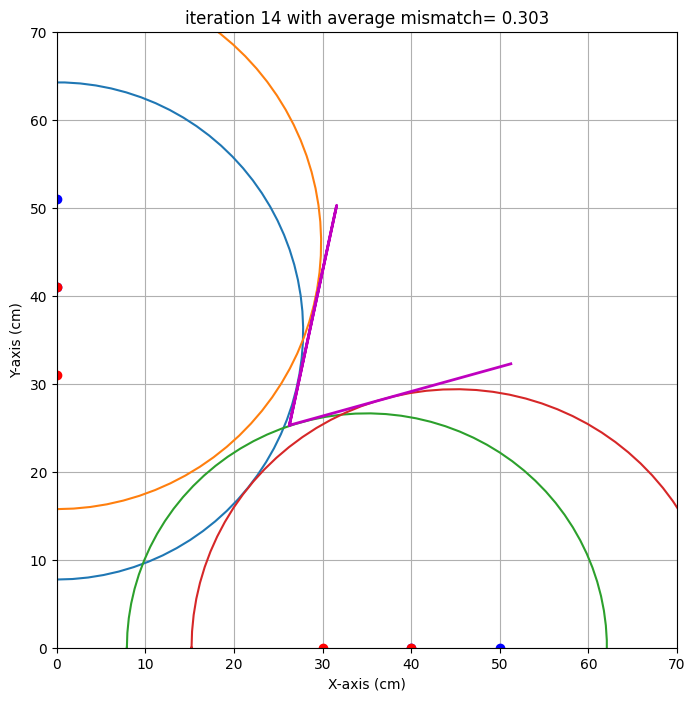

end iteration 14 with average mismatch= 0.303


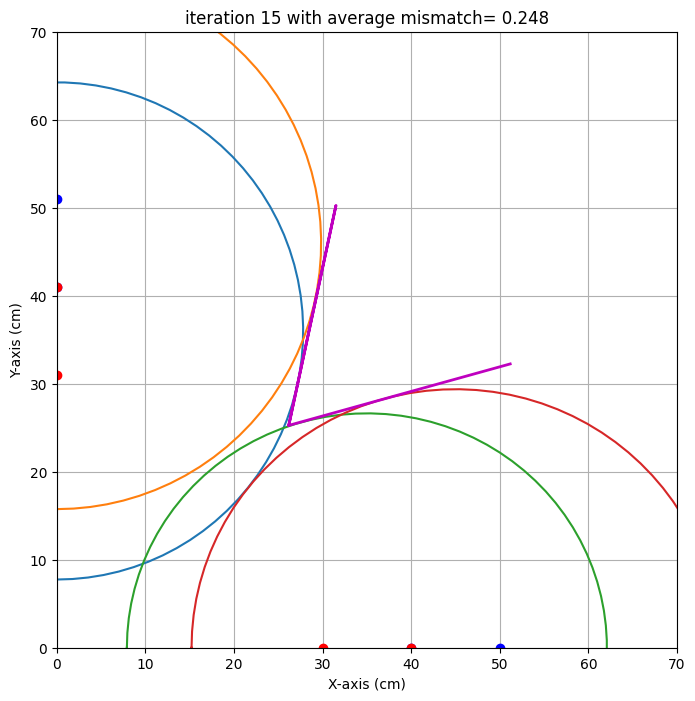

end iteration 15 with average mismatch= 0.248
end iteration 16 with average mismatch= 0.237
end iteration 17 with average mismatch= 0.234
end iteration 18 with average mismatch= 0.234
end iteration 19 with average mismatch= 0.234
end iteration 20 with average mismatch= 0.234
end iteration 21 with average mismatch= 0.234
end iteration 22 with average mismatch= 0.234
end iteration 23 with average mismatch= 0.234
end iteration 24 with average mismatch= 0.234
end iteration 25 with average mismatch= 0.234
end iteration 26 with average mismatch= 0.234
end iteration 27 with average mismatch= 0.234
end iteration 28 with average mismatch= 0.234
end iteration 29 with average mismatch= 0.234
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.234
###############################################################################
end of iteration  30
Best

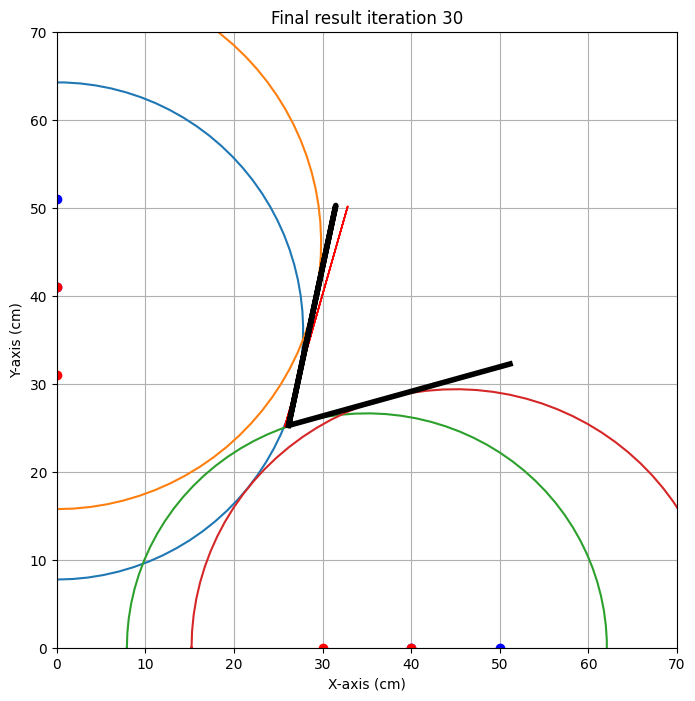

{'alpha': np.float64(15.61266793600388), 'alpha_eps': np.float64(0.009885907586289377), 'beta': np.float64(12.030195171512354), 'beta_eps': np.float64(3.809668751492886), 'x0': np.float64(26.156336835466636), 'x0_eps': np.float64(0.4183762217689342), 'y0': np.float64(25.2585871187698), 'y0_eps': np.float64(0.10937956133703963)}
locatie 1 
x0 target is : 45.0. Gevonden waarde: 41.3 cm met een standaardafwijking van 0.3 cm 
y0 target is : 39.0. Gevonden waarde: 41.5 cm met een standaardafwijking van 0.1 cm 
alpha target is : 24.0. Gevonden waarde: 8.8 graden met een standaardafwijking van 0.9 graad 
beta target is : -22.0. Gevonden waarde: -2.1 graden met een standaardafwijking van 1.9 graad 

locatie 2 
x0 target is : 24.0. Gevonden waarde: 26.2 cm met een standaardafwijking van 0.4 cm 
y0 target is : 25.0. Gevonden waarde: 25.3 cm met een standaardafwijking van 0.1 cm 
alpha target is : 17.0. Gevonden waarde: 15.6 graden met een standaardafwijking van 0.0 graad 
beta target is : 19.0. 

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 45,
                    'y0': 39,
                    'alpha' :24,
                    'beta' : -22},
           'locatie 2':{'x0': 24,
                    'y0': 25,
                    'alpha' : 17,
                    'beta' : 19}
            }

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [25.0, 0, 35.0, 0, 190]
    # [35, 0, 45, 0, 100]
    # [45, 0, 55, 0, 85]
    # [55, 0, 65, 0, 85.23]
    # [65, 0, 75, 0, 91.58]
    [0, 42.5, 0, 52.5, 82.73],
    [0, 47.5, 0, 57.5, 81.94],
    [44, 0, 54, 0, 85],
    [54, 0, 64, 0, 88],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [25, 0, 35, 0, 111],
    # [35, 0, 45, 0, 58],
    # [45, 0, 55, 0, 63.9],
    [0, 31, 0, 41, 56.5],
    # [0, 36, 0, 46, 57.4],
    [0, 41, 0, 51, 60.5],
    [30, 0, 40, 0, 54.2],
    # [35, 0, 45, 0, 75.6],
    [40, 0, 50, 0, 59.6]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 2 
x0 target is : 24.0. Gevonden waarde: 26.9 cm met een standaardafwijking van 3.0 cm 
y0 target is : 25.0. Gevonden waarde: 25.9 cm met een standaardafwijking van 1.5 cm 
alpha target is : 17.0. Gevonden waarde: 14.3 graden met een standaardafwijking van 11.2 graad 
beta target is : 19.0. Gevonden waarde: 9.3 graden met een standaardafwijking van 11.4 graad

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  34   0  44  40.2
1   0  44   0  54  33.0
2  24   0  34   0  62.3
3  34   0  44   0  64.7


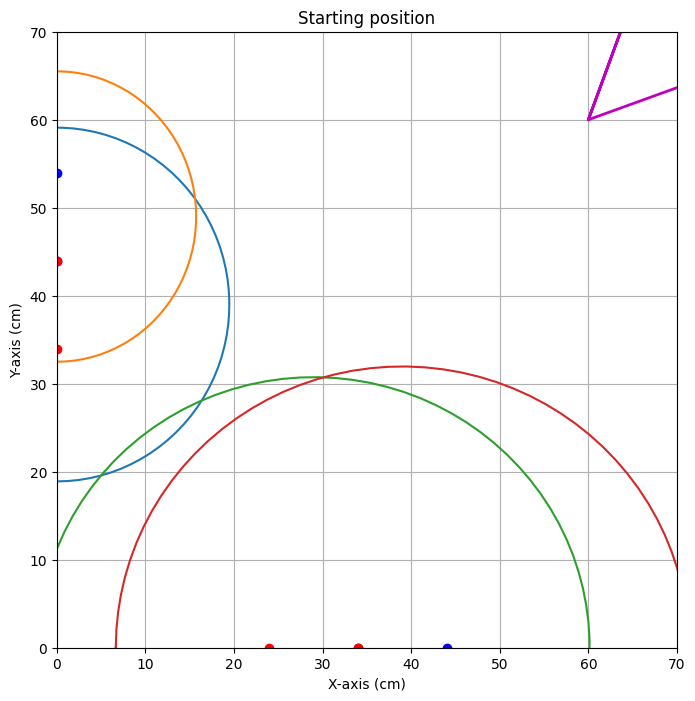


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=84.571


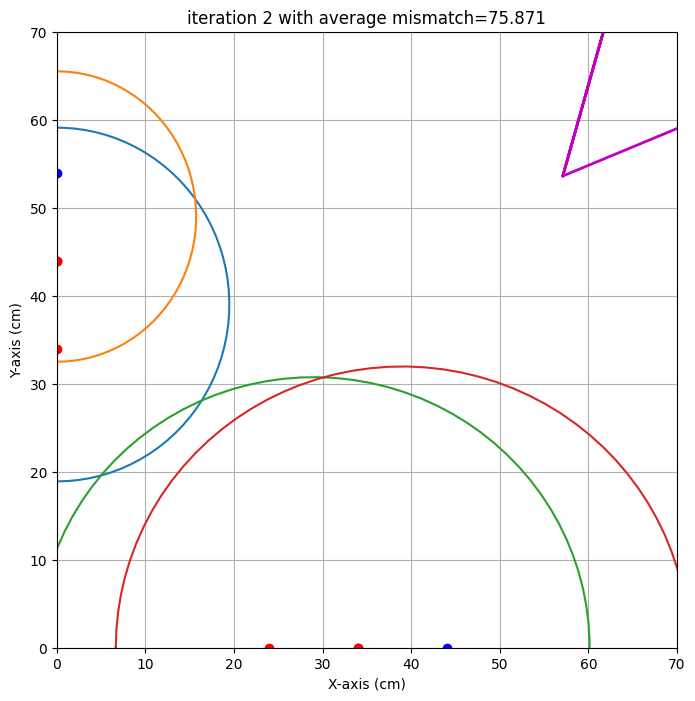

end iteration 2 with average mismatch=75.871


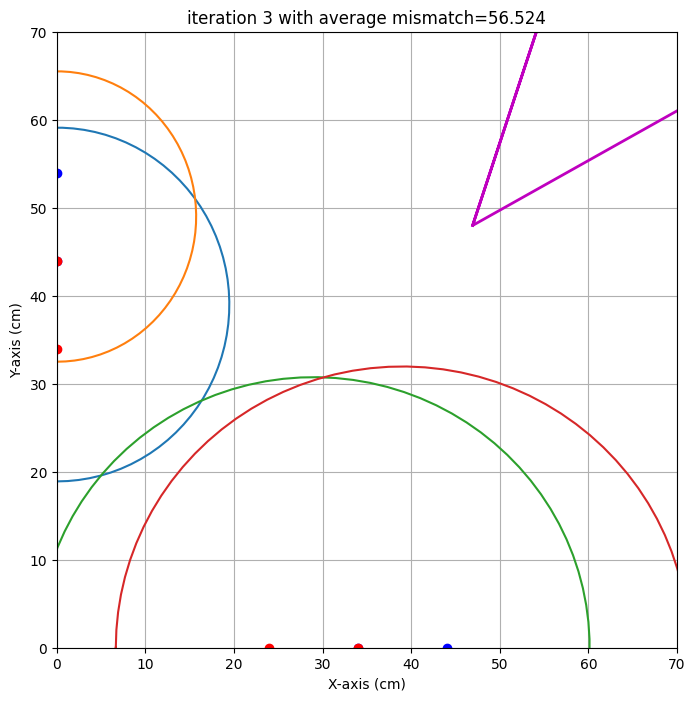

end iteration 3 with average mismatch=56.524


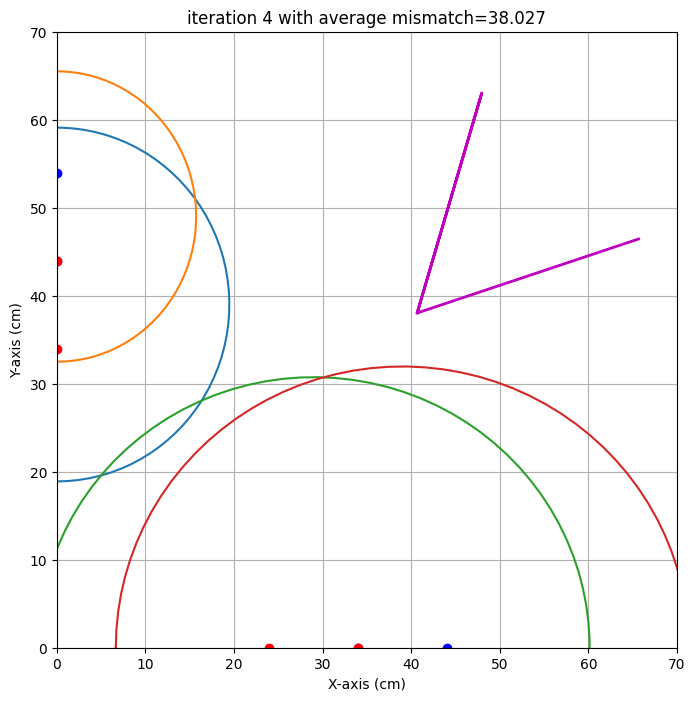

end iteration 4 with average mismatch=38.027


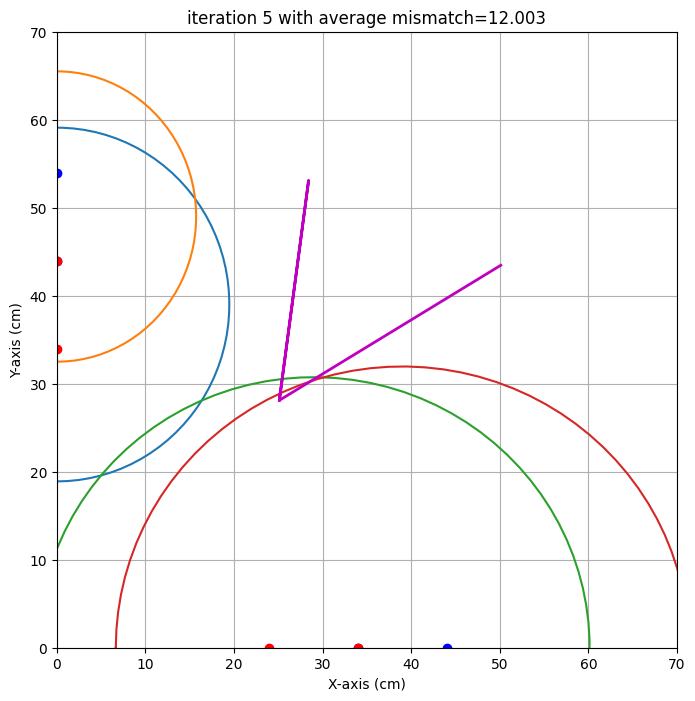

end iteration 5 with average mismatch=12.003


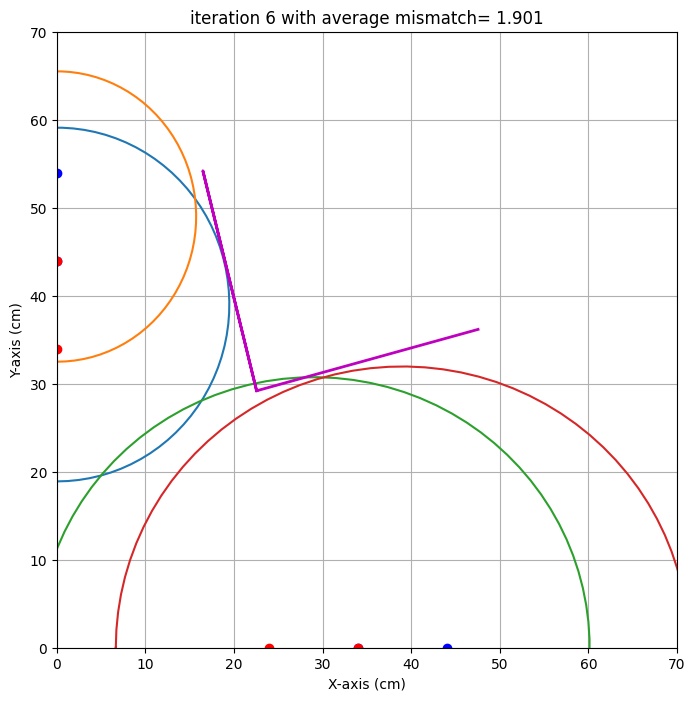

end iteration 6 with average mismatch= 1.901


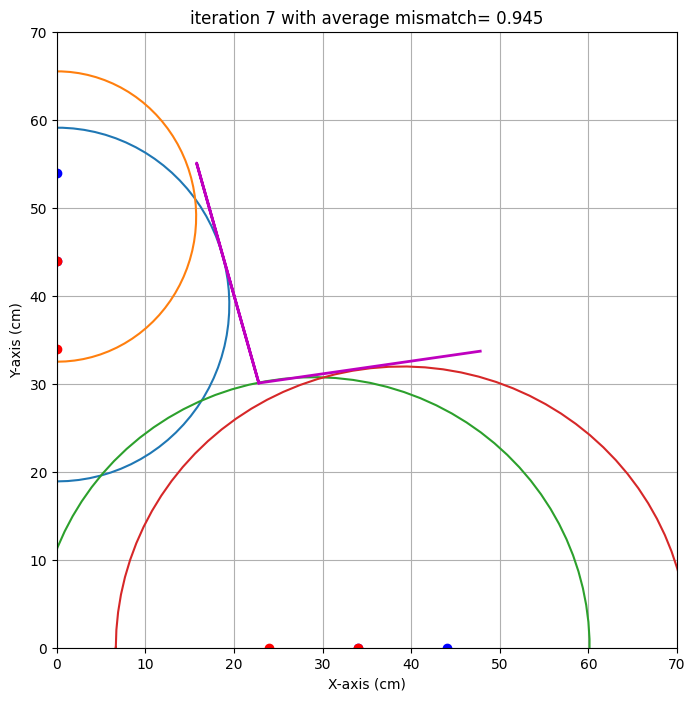

end iteration 7 with average mismatch= 0.945
end iteration 8 with average mismatch= 0.895


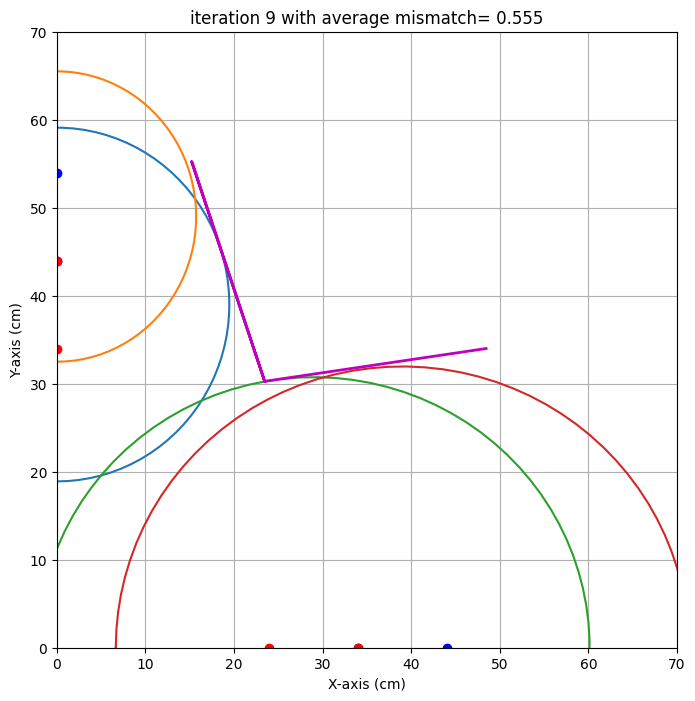

end iteration 9 with average mismatch= 0.555
end iteration 10 with average mismatch= 0.543
end iteration 11 with average mismatch= 0.543
end iteration 12 with average mismatch= 0.543
end iteration 13 with average mismatch= 0.543
end iteration 14 with average mismatch= 0.543
end iteration 15 with average mismatch= 0.543
end iteration 16 with average mismatch= 0.543
end iteration 17 with average mismatch= 0.543
end iteration 18 with average mismatch= 0.543
end iteration 19 with average mismatch= 0.543
end iteration 20 with average mismatch= 0.543
end iteration 21 with average mismatch= 0.543
end iteration 22 with average mismatch= 0.543
end iteration 23 with average mismatch= 0.543
end iteration 24 with average mismatch= 0.543
end iteration 25 with average mismatch= 0.491
end iteration 26 with average mismatch= 0.477
end iteration 27 with average mismatch= 0.476
end iteration 28 with average mismatch= 0.476
end iteration 29 with average mismatch= 0.476
Last iteration, also determine unce

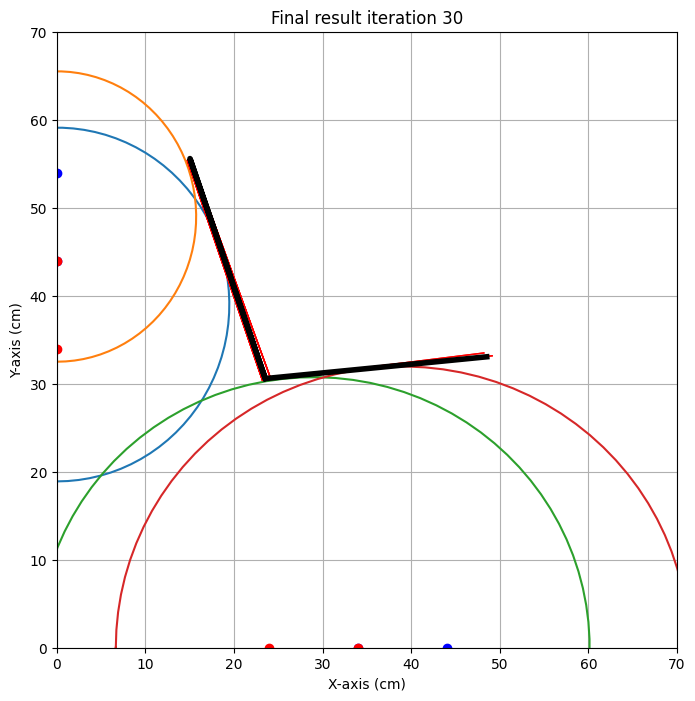

{'alpha': np.float64(5.655272779828644), 'alpha_eps': np.float64(1.4460596215519264), 'beta': np.float64(-18.783852553742797), 'beta_eps': np.float64(1.0710050485968985), 'x0': np.float64(23.526782062159974), 'x0_eps': np.float64(0.61620166948601), 'y0': np.float64(30.58430822165862), 'y0_eps': np.float64(0.20301210473436626)}
test locatie 
x0 target is : 21.5. Gevonden waarde: 23.5 cm met een standaardafwijking van 0.6 cm 
y0 target is : 30.0. Gevonden waarde: 30.6 cm met een standaardafwijking van 0.2 cm 
alpha target is : 5.0. Gevonden waarde: 5.7 graden met een standaardafwijking van 1.4 graad 
beta target is : -19.0. Gevonden waarde: -18.8 graden met een standaardafwijking van 1.1 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 21.5 ,
                    'y0':  30,
                    'alpha' : 5 ,
                    'beta' : -19  
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [25, 0, 35, 0, 64],
                    # [35, 0, 45, 0, 64.3],
                    [0, 34, 0, 44, 40.2],
                    [0, 44, 0, 54, 33],
                    [24, 0, 34, 0, 62.3],
                    [34, 0, 44, 0, 64.7],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

De x-waarde werd niet volledig bereikt binnen de marge, maar dat is mogelijk doordat de TA een deel van het papier buiten het 50-50 vlak had geplaatst, waardoor het x waarde toch goedgekeurd was. Zie foto eronder ter bewijs. TA: Casper

Papier buiten het vlak: ![Alt](Foutieve_papier.jpeg "Foutieve papier")


## Opdracht 11: Leerdoelen.
Startiteraties van elke student (Hendrik): ![Alt](iteratie_1.jpeg "StartIteratie")

Startiteraties van elke student (Meijne): ![Alt](iteratie_2.jpeg "StartIteratie")

Startiteraties van elke student (Xin Qi): ![Alt](iteratie_3.jpeg "StartIteratie")

Einditeratie: ![Alt](Eind_iteratie.jpeg "Einditeratie")


We hebben onze algoritmes besproken en vergeleken en zijn toen begonnen met iteratie 0 (zie eerste drie bovenstaande figuren). Hierin meten we eerst de x-as, dan de y-as, verder toeglicht in de blokschema's. We zagen dat de hoeken nog wat preciezer konden, we hebben hierna ons algoritme aangepast door een derde meting toe te voegen. De eerste meting van de x-as gebruikten we om een range op de y-as te vinden. Vervolgens konden we aan de hand van de metingen op de y-as de x-as nauwkeuriger meten waarbij we de oorspronkelijke x-waardes niet meer gebruikten in de eindberekening.